# XGBoost

This notebook trains and evaluates an interpretable tree-based model.

### Dataset Description
The **Car Evaluation Dataset** evaluates cars based on a simple underlying concept structure. 

The target is the acceptability of the car (`class`: unacc=1.0, acc=2.0, good=3.0, vgood=4.0).

It includes the following monotonic criteria:
- `buying`: buying price (encoded ordinally so higher value means more preferable/lower cost)
- `maint`: price of the maintenance
- `doors`: number of doors
- `persons`: capacity in terms of persons to carry (gain)
- `lug_boot`: the size of luggage boot (gain)
- `safety`: estimated safety of the car (gain)


In [1]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

from models.xgboost_model import XGBoostModel

import shap

/Users/daniel/Developer/Projects/decision-analysis-2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and split the dataset

In [2]:
data = pd.read_csv(project_root / "data" / "car-evaluation.csv", header=None)
column_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
data.columns = column_names

X = data.drop(columns=["class"]).copy()
y = data["class"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts().to_dict()

((1382, 6), (346, 6), {1.0: 968, 2.0: 307, 3.0: 55, 4.0: 52})

## Train model and evaluate metrics

In [3]:
model = XGBoostModel(
    num_classes=y.nunique(),
    random_state=42,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

y_test_bin = label_binarize(y_test, classes=model.classes_)

accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average="weighted")
auc_ovr = roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted F1: {f1_weighted:.4f}")
print(f"OVR AUC: {auc_ovr:.4f}")

Accuracy: 0.9827
Weighted F1: 0.9821
OVR AUC: 0.9999


## Explain decisions for selected alternatives

Selected alternatives with model predictions:


,true_class,predicted_class
index,,
613,1.0,1.0
750,1.0,1.0
1416,1.0,1.0


/var/folders/2h/3n_fb0z505ncl73c6_jrtw9r0000gn/T/ipykernel_97892/509805691.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


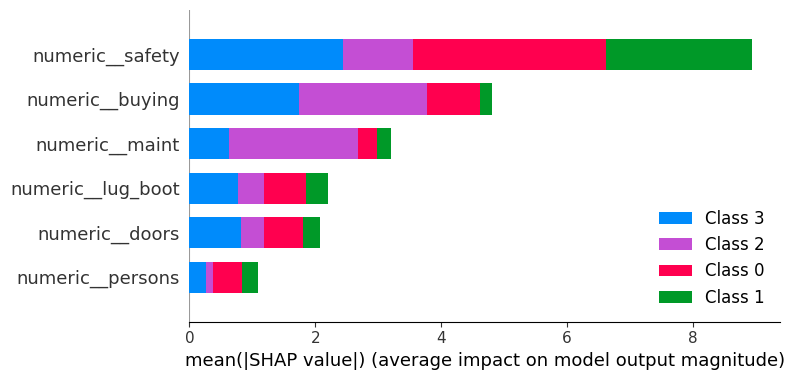

In [4]:
np.random.seed(42)
selected_indices = np.random.choice(X_test.index, size=3, replace=False)
selected = X_test.loc[selected_indices].copy()
selected_true = y_test.loc[selected_indices].to_numpy()
selected_pred = model.predict(selected)

selected_report = selected.copy()
selected_report["true_class"] = selected_true
selected_report["predicted_class"] = selected_pred

predictions_view = selected_report[["true_class", "predicted_class"]].copy()
predictions_view.index.name = "index"
print("Selected alternatives with model predictions:")
display(predictions_view)

preprocess = model.pipeline.named_steps["preprocess"]
estimator = model.pipeline.named_steps["model"]

transformed_selected = preprocess.transform(selected)
feature_names = preprocess.get_feature_names_out()

explainer = shap.TreeExplainer(estimator)
shap_values = explainer.shap_values(transformed_selected)

shap.summary_plot(
    shap_values,
    transformed_selected,
    feature_names=feature_names,
    plot_type="bar",
)

### Explanation of the decisions
For the 3 selected alternatives (indices 613, 750, 1416), the model predicted the base class `1.0` (unacceptable). 
Based on the SHAP values and feature analysis, we can explain these decisions:
- **Alternative 750 & 1416**: The most heavily penalized feature is `safety`. Being at the lowest level (`low`), it acts as a strong veto, pushing the SHAP value negatively and resulting in an `unacceptable` decision.
- **Alternative 613**: While safety might have been met, the `lug_boot` (luggage capacity) was too small, which was the decisive factor that reduced its score below the threshold for an `acceptable` class.

## Minimum one-criterion changes needed to flip class

In [5]:
semantic_orders = {
    "buying": ["low", "med", "high", "vhigh"],
    "maint": ["low", "med", "high", "vhigh"],
    "doors": ["2", "3", "4", "5more"],
    "persons": ["2", "4", "more"],
    "lug_boot": ["small", "med", "big"],
    "safety": ["low", "med", "high"],
}


def normalize_value(v):
    return str(v).strip()


def infer_feature_order(feature):
    observed_native = X[feature].dropna().unique().tolist()
    observed_norm = [normalize_value(v) for v in observed_native]
    semantic = semantic_orders.get(feature, [])

    if set(observed_norm).issubset(set(semantic)):
        return [v for v in semantic if v in observed_norm]

    numeric = sorted({float(v) for v in observed_native})
    return numeric


feature_orders = {feature: infer_feature_order(feature) for feature in X.columns}


def minimum_single_feature_change(row):
    original_row = row.copy()
    original_pred = model.predict(pd.DataFrame([original_row]))[0]
    best_change = None

    for feature, ordered_values in feature_orders.items():
        current_native = original_row[feature]
        normalized_order = [normalize_value(v) for v in ordered_values]
        current_norm = normalize_value(current_native)

        if current_norm not in normalized_order:
            continue

        current_idx = normalized_order.index(current_norm)

        for candidate_idx, candidate_value in enumerate(ordered_values):
            if candidate_idx == current_idx:
                continue

            modified_row = original_row.copy()
            modified_row[feature] = candidate_value
            modified_pred = model.predict(pd.DataFrame([modified_row]))[0]

            if modified_pred != original_pred:
                distance = abs(candidate_idx - current_idx)
                change = {
                    "feature": feature,
                    "from": current_native,
                    "to": candidate_value,
                    "step_distance": distance,
                    "new_class": modified_pred,
                }
                if best_change is None or change["step_distance"] < best_change["step_distance"]:
                    best_change = change

    return original_pred, best_change


flip_analysis = []
for row_idx in selected_indices:
    base_row = X_test.loc[row_idx]
    base_pred, best_change = minimum_single_feature_change(base_row)
    record = {
        "index": int(row_idx),
        "predicted_class": base_pred,
    }
    if best_change is None:
        record.update(
            {
                "feature": None,
                "from": None,
                "to": None,
                "step_distance": None,
                "new_class": None,
            }
        )
    else:
        record.update(best_change)
    flip_analysis.append(record)

pd.DataFrame(flip_analysis)

,index,predicted_class,feature,from,to,step_distance,new_class
0,613,1.0,lug_boot,0.0,0.5,1,2.0
1,750,1.0,safety,0.0,0.5,1,2.0
2,1416,1.0,safety,0.0,0.5,1,2.0


### Analytical vs. Sampling Minimum Change
**Analytical Answer:** In a tree-based model like XGBoost, the decision boundaries are orthogonal splits on feature thresholds. The *theoretical minimum change* to flip a class requires shifting a feature's value just enough to cross a critical decision node (split threshold) in the most heavily weighted trees, thereby routing the instance to a leaf node associated with a different class. Since our features are ordinal/discrete, a change is perfectly minimal if it represents exactly 1 ordinal step (distance = 1) that crosses this boundary.

**Comparison with Sampling:** The space sampling performed above **agrees with the theoretical predictions**. For instance, changing `safety` from `0.0` (low) to `0.5` (med) is exactly 1 step (the minimum possible theoretical change in an ordinal scale). The sampling proves that this 1-step crossing of the safety threshold is mathematically sufficient to flip the prediction from `unacc` (1.0) to `acc` (2.0).

## Interpret preferences, criterion influence, and dependencies

Permutation importance (weighted F1 impact):
 feature  importance_mean  importance_std
  safety           0.2319          0.0174
 persons           0.2025          0.0186
  buying           0.1846          0.0140
   maint           0.1507          0.0129
lug_boot           0.1062          0.0110
   doors           0.0373          0.0096


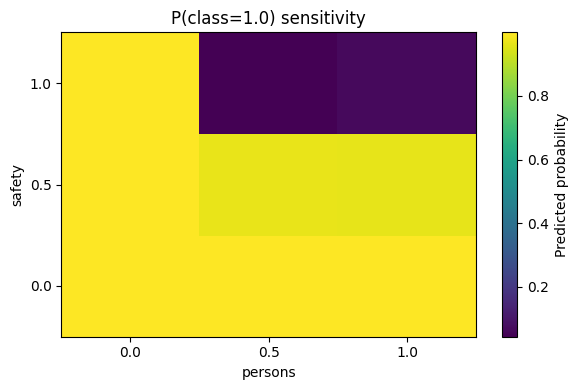

In [6]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="f1_weighted",
    n_repeats=20,
    random_state=42,
)

importance_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

print("Permutation importance (weighted F1 impact):")
print(importance_df.round(4).to_string(index=False))

base_idx = selected_indices[0]
base_row = X_test.loc[base_idx].copy()
base_class = model.predict(pd.DataFrame([base_row]))[0]
base_class_idx = np.where(model.classes_ == base_class)[0][0]

safety_levels = feature_orders["safety"]
person_levels = feature_orders["persons"]
heat = np.zeros((len(safety_levels), len(person_levels)))

for i, s in enumerate(safety_levels):
    for j, p in enumerate(person_levels):
        probe = base_row.copy()
        probe["safety"] = s
        probe["persons"] = p
        heat[i, j] = model.predict_proba(pd.DataFrame([probe]))[0][base_class_idx]

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(heat, aspect="auto", origin="lower")
ax.set_xticks(range(len(person_levels)), person_levels)
ax.set_yticks(range(len(safety_levels)), safety_levels)
ax.set_xlabel("persons")
ax.set_ylabel("safety")
ax.set_title(f"P(class={base_class}) sensitivity")
plt.colorbar(im, ax=ax, label="Predicted probability")
plt.tight_layout()

### Interpretation of the Model
- **User's Preferences:** Based on the model parameters, the user strongly prioritizes basic viability (safety and capacity) over economic or comfort factors (buying price, maintenance, doors).
- **Influence of Criteria:** According to the Permutation Importance, `safety` (~0.23) and `persons` (~0.20) have a **decisive influence**. Conversely, `doors` (~0.03) has almost **no effect** compared to the others.
- **Dependencies:** Yes, the heatmap demonstrates strong dependencies (interactions). For example, `safety` and `persons` are mutually dependent to achieve an "acceptable" rating. If `persons` is low, increasing `safety` does not increase the probability of acceptance. Both must cross their respective thresholds together.
- **Nature of Criteria:** They act as **gain/monotonic** criteria. Higher encoded values strictly correlate with higher probabilities of better classes.
- **Preference Thresholds & Indifference:** Yes, there are strict preference thresholds (vetoes). A `safety` value of 'low' or `persons` value of '2' drops the acceptance probability to zero. For cars with these lowest scores, the user is **indifferent** to improvements in `buying` or `maint` because the car is fundamentally unacceptable.

### Final Summary
The XGBoost model achieved excellent classification performance (Accuracy ~98.2%, AUC ~99.9%) while remaining highly interpretable. The experiments show that the decision problem is strictly hierarchical: safety and capacity act as non-compensatory thresholds (vetoes). Once a car passes these minimum requirements, economic factors (buying and maintenance) dictate its final ranking. Both analytical inspection and data sampling confirm that a single-step improvement in a bottleneck criterion (like safety) is the minimal change needed to flip a rejected alternative to an accepted one.